4주차 보스턴 회귀 코드

In [2]:
import kagglehub
1
# Download latest version
path = kagglehub.dataset_download("arunjangir245/boston-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'boston-housing-dataset' dataset.
Path to dataset files: /kaggle/input/boston-housing-dataset


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# boston 데이터 세트 로드
bostonDF = pd.read_csv("/kaggle/input/boston-housing-dataset/BostonHousing.csv")

# boston 데이터 세트 DataFrame 변환
# bostonDF = pd.DataFrame(boston.data , columns = boston.feature_names)

# boston 데이터 세트의 target 배열은 주택 가격임. 이를 PRICE 칼럼으로 DataFrame에 추가함

bostonDF['price'] = bostonDF["medv"]
bostonDF.drop('medv', axis = 1, inplace = True)
print('Boston 데이터 세트 크기 :',bostonDF.shape)
bostonDF.head()

Boston 데이터 세트 크기 : (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
bostonDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  price    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
bostonDF = bostonDF.dropna()

In [6]:
bostonDF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     501 non-null    float64
 1   zn       501 non-null    float64
 2   indus    501 non-null    float64
 3   chas     501 non-null    int64  
 4   nox      501 non-null    float64
 5   rm       501 non-null    float64
 6   age      501 non-null    float64
 7   dis      501 non-null    float64
 8   rad      501 non-null    int64  
 9   tax      501 non-null    int64  
 10  ptratio  501 non-null    float64
 11  b        501 non-null    float64
 12  lstat    501 non-null    float64
 13  price    501 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 58.7 KB


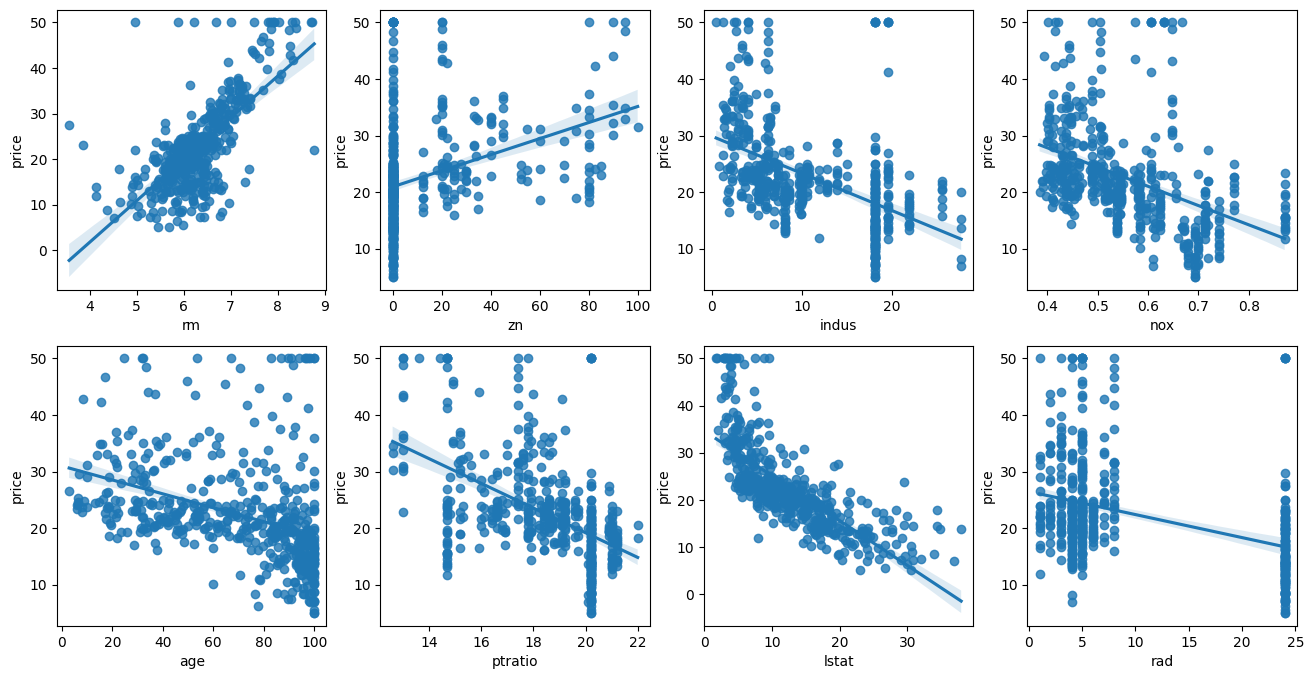

In [7]:
from matplotlib.figure import figaspect
# 2개의 행과 4개의 열을 가진 subplots를 이용 axs는 4x2개의 ax를 가짐
fig, axs = plt.subplots(figsize = (16, 8), ncols = 4, nrows = 2)
lm_features = ["rm", "zn", "indus", "nox", "age", "ptratio", "lstat", "rad"]

for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x = feature, y = "price", data = bostonDF, ax = axs[row][col])

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF["price"]
x_data = bostonDF.drop(["price"], axis = 1, inplace = False)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, test_size = 0.3, random_state = 156)

# 선형 회귀 OLS로 학습/예측/평가
lr = LinearRegression()
lr.fit(x_train, y_train)
y_preds = lr.predict(x_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print("MSE : {0:.3f}, RMSE : {1:.3F}".format(mse, rmse))
print("Variance score : {0:.3f}".format(r2_score(y_test, y_preds)))

MSE : 21.332, RMSE : 4.619
Variance score : 0.776


In [9]:
print("절편 값 :", lr.intercept_)
print("회귀 계수값 :", np.round(lr.coef_, 1))

절편 값 : 40.03259524337193
회귀 계수값 : [ -0.1   0.    0.1   1.6 -16.8   3.4   0.   -1.5   0.3  -0.   -0.9   0.
  -0.6]


In [10]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coef = pd.Series(data = np.round(lr.coef_, 1), index = x_data.columns)
coef.sort_values(ascending = False)

,0
rm,3.4
chas,1.6
rad,0.3
indus,0.1
zn,0.0
b,0.0
tax,-0.0
age,0.0
crim,-0.1
lstat,-0.6


In [11]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF["price"]
x_data = bostonDF.drop(["price"], axis = 1, inplace = False)
lr = LinearRegression()

# cross_val_score()로 5폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함
neg_mse_scores = cross_val_score(lr, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring = "neg_mean_squared_error")로 반환된 값은 모두 음수
print(" 5 folds의 개별 Negative MSE scores :", np.round(neg_mse_scores, 2))
print(" 5 folds의 개별 RMSE scores :", np.round(rmse_scores, 2))
print(" 5 folds의 평균 RMSE : {0:.3f}".format(avg_rmse))

 5 folds의 개별 Negative MSE scores : [-12.03 -29.28 -32.23 -88.23 -33.17]
 5 folds의 개별 RMSE scores : [3.47 5.41 5.68 9.39 5.76]
 5 folds의 평균 RMSE : 5.942


# 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

## 규제 선형 모델의 개요

회귀 모델은 적절히 데이터에 적합하면서도 회귀 계수가 기하급수적으로 커지는 것을 제어할 수 있어야 합니다.

지금까지 공부 했던 모델의 비용 함수는 RSS를 최소화하는, 즉 실제 값과 예측값의 차이를 최소화하는 것만 고려했었습니다. 그러다 보니 학습 데이터에 지나치게 맞추게 되고, 회귀 계수가 쉽게 커졌습니다. 이럴 경우 변동성이 오히려 심해져서 테스트 데이터 세트에서는 예측 성능이 저하되기 쉽습니다. 이를 반영하여 비용 함수는 학습 데이터의 잔차 오류 값을 최소로 하는 RSS 최소화 방법과 과적합을 방지하기 위해 회귀 계수 값이 커지지 않도록 하는 방법이 서로 균형을 이루어야 합니다.

$$
\text{목표 함수} = \min \left( RSS(W) + \alpha \|W\|_2^2 \right)
$$

여기서 alpha는 학습 데이터 적합 정도와 회귀 계수 값의 크기 제어를 수행하는 튜닝 파라미터입니다. 비용 함수 목표가 $$
\text{목표 함수} = \min \left( RSS(W) + \alpha \|W\|_2^2 \right)
$$를 최소화하는 W 벡터를 찾는 것일 때 alpha가 어떤 역할을 하는지 알아보도록 하겠습니다.

alpha가 0(또는 매우 작은 값)이라면 비용 함수 식은 기존과 동일한 $$
\text{목표 함수} = \min \left( RSS(W) + 0 \right)
$$이 될 것입니다. 반면에 너무 alpha가 무한대(또는 매우 큰 값)라면 비용 함수 식은 RSS(W)에 비해 $$
\left( \alpha \|W\|_2^2 \right)
$$ 값이 너무 커지게 되므로 W 값을 0(또는 매우 작게)으로 만들어야 Cost가 최소화되는 비용 함수 목표를 달성할 수 있습니다.

즉, alpha 값을 크게 하면 비용 함수는 회귀 계수 W의 값을 작게 해 과적합을 개선할 수 있으며 alpha 값을 작게 하면 회귀 계수 W의 값이 커져도 어느 정도 상쇄가 가능하므로 학습 데이터 적합을 더 개선할 수 있습니다.

* alpha = 0인 경우는 W가 커도 alpha * \|W\|_2^2가 0이 되어 비용 함수는 Min(RSS(W))
* alpha = 무한대인 경우 alpha * \|W\|_2^2도 무한대가 되므로 비용 함수는 W를 0으로 가깝게 최소화 해야 함

-> alpha를 0에서부터 지속적으로 값을 증가시키면 회귀 계수 값의 크기를 감소시킬 수 있다.

이처럼 비용 함수에 alpha 값으로 패널티를 부여해 회귀 계수 값의 크기를 감소시켜 과적합을 개선하는 방식을 규제(Regularization)라고 부릅니다.

규제는 크게 L2 방식과 L1 방식으로 구문됩니다. L2 규제는 위에서 설명한 바와 같이 \|W\|_2^2와 같이 W의 제곱에 대해 패널티를 부여하는 방식을 말합니다. L2 규제를 적용한 회귀를 릿지(Ridge) 회귀라고 합니다. 라쏘(Lasso) 회귀는 L1 규제를 적용한 회귀입니다. L1 규제는 \|W\|_2^2와 같이 W의 절댓값에 대해 패널티를 부여합니다. L1 규제를 적용하면 영향력이 크지 않은 회귀 계수 값을 0으로 변환합니다.

## 릿지 회귀

사이킷 런의 Ridge 클래스의 주요 생성 파라미터는 alpha이며, 이는 릿지 회귀의 alpha L2 규제 계수에 해당합니다.

In [12]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha = 10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha=10)
neg_mean_scores = cross_val_score(ridge, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
ave_rmse = np.mean(rmse_scores)
print(" 5 folds의 개별 Negative MSE scores :", np.round(neg_mse_scores, 3))
print(" 5 folds의 개별 RMSE scores :", np.round(rmse_scores, 3))
print(" 5 folds의 평균 RMSE :", np.round(ave_rmse, 3))

 5 folds의 개별 Negative MSE scores : [-12.03  -29.277 -32.233 -88.233 -33.166]
 5 folds의 개별 RMSE scores : [3.468 5.411 5.677 9.393 5.759]
 5 folds의 평균 RMSE : 5.942


릿지의 alpha 값을 0, 0.1, 1, 10, 100으로 변환시키면서 RMSE와 회귀 계수 값을 변화 살펴보기

In [13]:
# 릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

# alphas 리스트 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, x_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print("alpha {0} 일 때 5 folds의 평균 RMSE : {1:.3f}".format(alpha, avg_rmse))

alpha 0 일 때 5 folds의 평균 RMSE : 5.942
alpha 0.1 일 때 5 folds의 평균 RMSE : 5.903
alpha 1 일 때 5 folds의 평균 RMSE : 5.769
alpha 10 일 때 5 folds의 평균 RMSE : 5.624
alpha 100 일 때 5 folds의 평균 RMSE : 5.398


alpha 값의 변화에 따른 피처의 회귀 계수 값을 가로 막대 그래프로 확인해보기

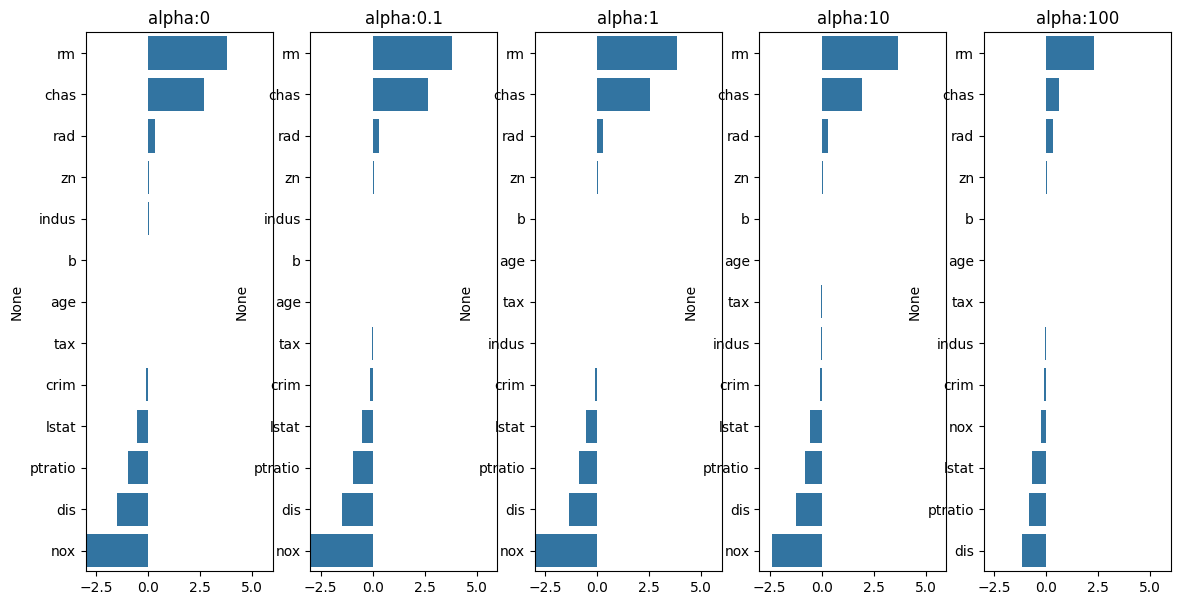

In [14]:
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize = (14, 7), nrows = 1, ncols = 5)
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 기가화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(x_data, y_target)
    # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
    coeff = pd.Series(data = ridge.coef_, index = x_data.columns)
    colname = 'alpha:' + str(alpha)
    coeff_df[colname] = coeff
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화, 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending = False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3, 6)
    sns.barplot(x = coeff.values, y = coeff.index, ax = axs[pos])

# for 문 바깥에서 맷플롯ㄹ비의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()

alpha 값을 계속 증가시킬수록 회귀 계수 값은 지속적으로 작아짐을 확인 할 수 있습니다. 특히 NOX 피처의 경우 alpha 값을 계속 증가시킴에 따라 회귀 계수가 크게 작아지고 있습니다.

In [15]:
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:' + str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending = False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
rm,3.781141,3.790072,3.828795,3.680888,2.317671
chas,2.667336,2.650597,2.533137,1.936759,0.633636
rad,0.305855,0.303311,0.289906,0.279364,0.315210
zn,0.045483,0.045644,0.046571,0.048769,0.053612
indus,0.014017,0.009462,-0.015283,-0.049456,-0.060326
b,0.009321,0.009379,0.009691,0.010061,0.009412
age,0.001969,0.000980,-0.004306,-0.009786,0.001986
tax,-0.012224,-0.012315,-0.012832,-0.013946,-0.015812
crim,-0.108580,-0.108030,-0.105084,-0.101836,-0.102546
lstat,-0.523613,-0.524847,-0.532358,-0.558537,-0.659749


## 라쏘 회귀

W의 절댓값에 패널티를 부여하는 L1 규제를 선형 회귀에 적용한 것이 라쏘(Lasso) 회귀입니다. 즉 L1 규제는 \|W\|_1를 의미하며, 라쏘 회귀 비용함수의 목표는 RSS(W) + \|W\|_1 식을 최소화하는 W를 찾는 것입니다. L2 규제가 회귀 계수의 크기를 감소시키는 데 반해, L1 규제는 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거합니다. 이러한 측면에서 L1 규제는 적절한 피처만 회귀에 포함시키는 피처 선택의 특성을 가지고 있습니다.

In [16]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, x_data_n=None, y_target_n = None, verbose = True, return_coeff = True):
    coeff_df = pd.DataFrame()
    if verbose : print("######", model_name, "######")
    for param in params:
        if model_name == "Ridge":
            model = Ridge(alpha = param)
        elif model_name == "Lasso":
            model = Lasso(alpha = param)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha = param, l1_ratio = 0.7)
        neg_mse_scores = cross_val_score(model, x_data_n, y_target, scoring = "neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print("alpha {0}일 때 5 폴드 세트의 평균 RMSE : {1:.3f}".format(param, avg_rmse))
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(x_data_n, y_target_n)
        if return_coeff:
            # alpha에 다른 피처별ㄹ 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
            coeff = pd.Series(data = model.coef_, index = x_data_n.columns)
            colname = "alpha:"+str(param)
            coeff_df[colname] = coeff

    return coeff_df

# end of get_linear_regre_eval
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval("Lasso", params = lasso_alphas, x_data_n = x_data, y_target_n = y_target)

###### Lasso ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.721
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.720
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.723
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.796
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.241


In [17]:
# 반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀 계수 DataFrame 출력
sort_column = "alpha:" + str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.771733,3.686219,2.491564,0.961131,0.000000
chas,1.424099,0.949233,0.000000,0.000000,0.000000
rad,0.270698,0.274443,0.277489,0.266887,0.065590
zn,0.048258,0.048398,0.048688,0.048476,0.036792
b,0.010279,0.010281,0.009509,0.008313,0.006617
nox,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
age,-0.010808,-0.009138,0.004406,0.021414,0.043164
tax,-0.014254,-0.014533,-0.015414,-0.015428,-0.008908
indus,-0.048381,-0.042941,-0.012138,-0.000000,-0.000000
crim,-0.098607,-0.098319,-0.083890,-0.064006,-0.000000


alpha의 크기가 증가함에 따라 일부 피처의 회귀 계수는 아예 0으로 바뀌고 있습니다. NOX 속성은 alpha가 0.07일 때부터 회귀 계수가 0이며, alpha를 증가시키면서 INDUS, CHAS와 같은 속성의 회귀 계수가 0으로 바뀝니다. 회귀 계수가 0인 피처는 회귀 식에서 제외되면서 피처 선택의 효과를 얻을 수 있습니다.

## 엘라스틱넷 회귀

엘라스틱넷 회귀는 L2 규제와 L1 규제를 결합한 회귀입니다. 따라서 엘라스틱넷 회귀 비용 함수의 목표는 $$
RSS(W) + \alpha2 \|W\|_2^2 + \alpha1 \|W\|_1
$$ 식을 최소화하는 W를 찾는 것입니다. 엘라스틱넷은 라쏘 회귀가 서로 상관관계가 높은 피처들의 경우에 이들 중에서 중요 피처만을 셀렉션하고 다른 피처들은 모두 회귀 계수를 0으로 만드는 성향이 강합니다. 특히 이러한 성향으로 인해 alpha값에 따라 회귀 계수의 값이 급격히 변동할 수도 있는데, 엘라스틱넷 회귀는 이를 완화하기 위해 L2 규제를 라쏘 회귀에 추가한 것입니다. 반대로 엘라스틱넷 회귀의 단점은 L1과 L2 규제가 결합된 규제로 인해 수행 시간이 상대적으로 오래 걸린다는 것입니다.

ElasticNet 클래스의 주요 생성 파라미터는 alpha와 l1_ratio입니다. ElasticNet 클래스의 alpha는 Ridge와 Lasso 클래스의 alpha 값과는 다릅니다. 엘라스틱넷의 규제는 a * L1 + b * L2로 정의될 수 있으며, 이때 a는 L1 규제의 alpha값, b는 L2 규제의 alpha값입니다. 따라서 ElasticNet 클래스의 alpha 파라미터 값은a + b입니다. ElasticNet 클래스의 l1_ratio 파라미터 값은 a / (a + b)입니다. l1_ratio가 0이면 a가 0이므로 L2 규제와 동일합니다. l1_ratio가 1이면 b가 0이므로 L1 규제와 동일합니다.

ElasticNet 클래스를 이용해 바로 이전의 릿지, 라쏘 회귀 예제 코드와 유사하게 엘라스틱넷 alpha 값을 변화시키면서 RMSE와 각 피처의 회귀 계수를 출력해 보겠습니다.

In [18]:
# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ratio는 0.7로 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval("ElasticNet", params = elastic_alphas, x_data_n = x_data, y_target_n = y_target)

###### ElasticNet ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE : 5.643
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.619
alpha 0.5일 때 5 폴드 세트의 평균 RMSE : 5.510
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.625
alpha 3일 때 5 폴드 세트의 평균 RMSE : 6.097


In [19]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 낼미차순 정렬해 회귀계수 DataFrame 출력
sort_column = "alpha:" + str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.557177,3.399152,1.914392,0.940941,0.000000
chas,1.324462,0.975982,0.000000,0.000000,0.000000
rad,0.278688,0.283120,0.300731,0.290006,0.150973
zn,0.049282,0.049788,0.051984,0.051259,0.037817
b,0.010148,0.010096,0.009149,0.008364,0.007102
age,-0.009213,-0.007442,0.008450,0.020981,0.044174
tax,-0.014475,-0.014771,-0.016011,-0.016230,-0.011721
indus,-0.051148,-0.049345,-0.030696,-0.006817,-0.000000
crim,-0.099888,-0.099614,-0.089594,-0.074244,-0.020174
nox,-0.229132,-0.000000,-0.000000,-0.000000,-0.000000


## 선형 회귀 모델을 위한 데이터 변환

선형 회귀 모델고 ㅏ같은 선형 모델은 일반적으로 피처와 타깃값 간에 선형의 관계가 있다고 가정하고, 이러한 최적의 선형함수를 찾아 결괏값을 예측합니다. 또한 선형 회귀 몯레은 피처값과 타깃값의 분포가 정규 분포(즉 평균을 중심으로 종 모양으로 데이터 값이 분포된 형태) 형태를 매우 선호합니다. 특히 타깃값의 경우 정규 분포 형태가 아니라 특정값의 분포가 치우친 왜곡(Skew)된 형태의 분포도일 경우 예측 성능에 부정적인 영향을ㄹ 미칠 가능성이 높습니다. 피척밧 역시 결정값보다는 덜하지만 왜곡된 분포도로 인해 예측 성능에 부정적인 영향을 미칠 수 있습니다.

따라서 선형 회귀 모델을 적용하기 전에 먼저 데이터에 대한 스케일링 / 정규화 작업을 수행하는 것이 일반적입니다. 하지만 이러한 스케일링 / 정규화 작업을 선행한다고 해서 무조건 예측 성능이 향상되는 것은 아닙니다. 일반적으로 중요 피처들이나 타깃값의 분포도가 심하게 왜곡됐을 경우 이러한 변환 작업을 수행합니다.

일반적으로 피처 데이터 세트와 타깃 데이터 세트에 이러한 스케일링 / 정규화 작업을 수행하는 방법이 조금은 다릅니다. 먼저 사이킷런을 이용해 피처 데이터 세트에 적용하는 변화나 작업은 다음과 같은 방법이 있을 수 있습니다.

1) StandardScaler 클래스를 이용해 평균이 0, 분산이 1인 표준 정규 분포를 가진 데이터 세트로 변환하거나 MinMaxScaler 클래스를 이용해 최솟값이 0이고 최댓값이 1인 값으로 정규화를 수행합니다.
2) 스케일링 / 정규화를 수행한 데이터 세트에 다시 다항 특성을 적용하여 변환하는 방법입니다. 보통 1번 방법을 통해 예측 성능에 향상이 없을 경우 이와 같은 방법을 적용합니다.
3) 원래 값에 log 함수를 적용하면 보다 정규 분포에 가까운 형태로 값이 분포됩니다. 이러한 변환을 로그 변환(Log Transformatio)이라고 부릅니다. 로그 변환은 매우 유용한 변환이며, 실제로 선형 회귀에서는 앞에서 소개한 1,2번 방법보다 로그 변환이 훨씬 많이 사용되는 변환 방법입니다. 왜냐하면 1번 방법의 경우 예측 성능 향상을 크게 기대하기 어려운 경우가 많으며 2번 방법의 경우 피처의 개수가 매우 많을 경우에는 다항 변환으로 생성되는 피처의 개수가 기하급수로 늘어나서 과적합의 이슈가 발생할 수 있습니다.

타깃값의 경우는 일반적으로 로그 변환을 적용합니다. 결정 값을 정규 값을 정규 분포나 다른 정규값으로 변환하면 변환된 값을 다시 원본 타깃값으로 원복하기 어려울 수 있습니다. 무엇보다도, 왜곡된 분포도 형태의 타깃값을 로그 변환하여 예측 성능 향상이 된 경우가 많은 사례에서 검증되었기 때문에 타깃값의 경우는 로그 변환하여 예측 성능 향상이 된 경우가 많은 사례에서 검증되었기 때문에 타깃값의 경우는 로그 변환을 적용합니다.

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최댓값/최솟값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다항식 즉성을 추가할 때 적용, p_degree는 2이상 부여하지 않음
def get_scaled_data(method = "None", p_degree = None, input_data = None):
    if method == "Standard":
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == "MinMax":
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == "Log":
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree = p_degree, include_bias = False).fit_transform(scaled_data)

    return scaled_data

In [21]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규 분포, 표준정규 분포 + 다항식 특성
# 최대 / 최소 정규화, 최대 / 최소 정규화 + 다항식 특성, 로그변환
scale_methods = [(None, None), ("Standard", None), ("Standard", 2), ("MinMax", None), ("MinMax",2), ("Log", None)]

for scale_method in scale_methods:
    x_data_scaled = get_scaled_data(method = scale_method[0], p_degree = scale_method[1], input_data = x_data)
    print("\n## 변환 유형 :{0}, Polynomial Degree :{1}".format(scale_method[0], scale_method[1]))
    get_linear_reg_eval("Ridge", params = alphas, x_data_n = x_data, y_target_n = y_target, verbose = False, return_coeff = False)


## 변환 유형 :None, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Standard, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Standard, Polynomial Degree :2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :MinMax, Polynomial Degree :None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :MinMax, Polynomial Degree :2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE : 5.903
alpha 1일 때 5 폴드 세트의 평균 RMSE : 5.769
alpha 10일 때 5 폴드 세트의 평균 RMSE : 5.624
alpha 100일 때 5 폴드 세트의 평균 RMSE : 5.398

## 변환 유형 :Log, Polynomial Degree :None
alph

피처의 개수가 많을 경우 적용하기 힘들며, 또한 데이터 건수가 많아지면 계산에 많은 시간이 소모되어 적용에 한계가 있습니다. 반면에 로그 변환을 보면 alpha가 0.1, 1, 10인 경우에 모두 좋은 성능 향상이 있음을 알 수 있습니다.

일반적으로 선형 회귀를 적용하려는 데이터 세트에 데이터 값의 분포가 심하게 왜곡되어 있을 경우에 이처럼 로그 변환을 적용하는 것이 좋은 결과를 기대할 수 있습니다.

## 로지스틱 회귀

로지스틱 회귀는 선형 회귀 방식을 분류에 적용한 알고리즘입니다. 즉, 로지스틱 회귀는 분류에 사용됩니다. 로지스틱 회귀 역시 선형 회귀 계열입니다. 회귀가 선형인가 비선형인가는 독립변수가 아닌 가중치(weight) 변수가 선형인지 아닌지를 따릅니다. 로지스틱 회귀가 선형 회귀와 다른 점은 학습을 통해 선형 함수의 회귀 최적선을 찾는 것이 아니라 시그모이드(Sigmoid) 함수 최적선을 찾고 이 시그모이드 함수의 반환 값을 확률로 간주해 확률에 따라 분류를 결정합니다.

시그모이드 함수의 정의는 $y=\frac{1}{1+e^{-z}}$입니다. 식에서 알 수 있듯이 시그모이드 함수는 x값이 +,-로 아무리 커지거나 작아져도 y값은 항상 0과 1 사이 값을 반환합니다. x값이 커지면 1에 근사하며 x값이 작아지면 0에 근사합니다. 그리고 x가 0일때는 0.5입니다.

LogisticRegression 클래스에서 solver 파라미터의 "lbfgs", "liblinear", "newton-cg", "sag", "saga" 값을 적용해서 최적화를 선택할 수 있습니다.

* lbfgs : 사이킷런 버전 0.22부터 solver의 기본 설정값입니다. 메모리 공간을 절약할 수 있고, CPU코어 수가 많다면 최적화를 병렬로 수행할 수 있습니다.
* liblinear : 사이킷런 버전 0.21까지에서의 solver의 기본 설정값입니다. 다차원이고 작은 데이터 세트에서 효과적으로 동작하지만 국소 최적화(Local Minimum)에 이슈가 있고, 병렬로 최적화할 수 없습니다.
* newton-cg : 좀 더 정교한 최적화를 가능하게 하지만, 대용량의 데이터에서 속도가 많이 느려집니다.
* sag : Stochastic Average Gradient로서 경사 하강법 기반의 최적화를 적용합니다. 대용량의 데이터에서 빠르게 최적화합니다.
* saga : sag와 유사한 최적화 방식이며 L1 정규화를 가능하게 해줍니다.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

x_train, x_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size = 0.3, random_state = 0)

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행
# solver 인자값을 생성자로 입력하지 않으면 solver = "lbfgs"
lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)

lr_preds = lr_clf.predict(x_test)
lr_preds_proba = lr_clf.predict_proba(x_test)[:,1]

# accuracy와 roc_auc 측정
print("accuracy : {0:.3f}, roc_auc : {1:.3f}".format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

accuracy : 0.977, roc_auc : 0.995


max_iter = 600이면 최적화 알고리즘이 수렴할 때까지 최대 600번까지 반복하여 회귀 계수를 최적화합니다.

In [25]:
solvers = ["lbfgs", "liblinear", "newton-cg", "sag", "saga"]

# 여러 개의 solver 값별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver = solver, max_iter = 600)
    lr_clf.fit(x_train, y_train)
    lr_preds = lr_clf.predict(x_test)
    lr_preds_proba = lr_clf.predict_proba(x_test)[:,1]

    # accuracy와 roc_auc 측정
    print("solver :{0}, accuracy : {1:.3f}, roc_auc :{2:.3f}".format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

solver :lbfgs, accuracy : 0.977, roc_auc :0.995
solver :liblinear, accuracy : 0.982, roc_auc :0.995
solver :newton-cg, accuracy : 0.977, roc_auc :0.995
solver :sag, accuracy : 0.982, roc_auc :0.995
solver :saga, accuracy : 0.982, roc_auc :0.995


Solver와 max_iter 외에 사이킷런 LogisticRegression 클래스의 주요 하이퍼 파라미터로 penalty와 C가 있습니다. penalty는 규제(Regularization)의 유형을 설정하며 'l2'로 설정 시 L2 규제를, 'l1'으로 설정 시 L1 규제를 뜻합니다. 기본은 'l2'입니다. C는 규제 강도를 조절하는 alpha 값의 역수입니다. 즉, C = 1 / alpha입니다. C 값이 작을수록 규제 강도가 큽니다.

L1, L2 규제의 경우 solver 설정에 따라 영향을 받습니다. Liblinear, saga의 경우 L1, L2 규제가 모두 가능하지만 lbfgs, newton-cg, sag의 경우는 L2 규제만 가능합니다.

In [26]:
from sklearn.model_selection import GridSearchCV

params = {"solver" : ["liblinear", "lbfgs"],
          "penalty" : ["l2", "l1"],
          "C" : [0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = "accuracy", cv = 3)
grid_clf.fit(data_scaled, cancer.target)
print("최적 하이퍼 파라미터 : {0}, 최적 평균 정확도 : {1:.3f}".format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터 : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도 : 0.979


로지스틱 회귀는 가볍고 빠르지만, 이진 분류 예측 성능도 뛰어납니다. 이 때문에 로지스틱 회귀를 이진 분류의 기본 모델로 사용하는 경우가 많습니다. 또한 로지스틱 회귀는 희소한 데이터 세트 분류에도 뛰어난 성능을 보여서 텍스트 분류에서도 자주 사용됩니다.